# Prelim — Read in Marijuana Legalization & Unemployment Data

Just reads the raw files. No cleaning, merging, or reshaping yet.

In [39]:
import pandas as pd
from pathlib import Path
import matplotlib.pyplot as plt
import statsmodels.formula.api as smf

RAW = Path('../data/raw')

## Legalization dates

In [2]:
dates = pd.read_csv(RAW / 'legalization_dates.csv')
dates

,state,fips,medical_year,recreational_vote_year,recreational_sales_year
0,CA,6,1996.0,2016.0,2018.0
1,CO,8,2000.0,2012.0,2014.0
2,WA,53,1998.0,2012.0,2014.0
3,OR,41,1998.0,2014.0,2015.0
4,AK,2,1998.0,2014.0,2016.0
5,NV,32,2000.0,2016.0,2017.0
6,ME,23,1999.0,2016.0,2020.0
7,MA,25,2012.0,2016.0,2018.0
8,ID,16,NaN,NaN,NaN
9,WY,56,NaN,NaN,NaN


## State unemployment-rate series

In [3]:
state_files = sorted(RAW.glob('*UR.csv'))
print(f"Found {len(state_files)} state series:", [f.stem for f in state_files])

Found 13 state series: ['AKUR', 'CAUR', 'COUR', 'IDUR', 'KSUR', 'MAUR', 'MEUR', 'NEUR', 'NVUR', 'ORUR', 'UTUR', 'WAUR', 'WYUR']


In [4]:
ur_raw = {f.stem.replace('UR', ''): pd.read_csv(f) for f in state_files}
ur_raw['CO'].head()

,observation_date,COUR
0,1976-01-01,5.8
1,1976-02-01,5.8
2,1976-03-01,5.7
3,1976-04-01,5.6
4,1976-05-01,5.6


## Combine into one long panel

Rename each state's UR column to a common name, tag it with the state code, and stack all 13 into a single `state, date, ur` DataFrame.

In [5]:
panels = []
for state, raw in ur_raw.items():
    df = raw.rename(columns={f'{state}UR': 'ur'})
    df['state'] = state
    panels.append(df)

ur = pd.concat(panels, ignore_index=True)
ur['date'] = pd.to_datetime(ur['observation_date'])
ur = ur.drop(columns='observation_date')
ur = ur[['state', 'date', 'ur']].sort_values(['state', 'date']).reset_index(drop=True)

print(f"{ur.shape[0]} rows, {ur['state'].nunique()} states, "
      f"{ur['date'].min().date()} to {ur['date'].max().date()}")
ur.head()

7857 rows, 13 states, 1976-01-01 to 2026-05-01


,state,date,ur
0,AK,1976-01-01,7.1
1,AK,1976-02-01,7.1
2,AK,1976-03-01,7.0
3,AK,1976-04-01,7.0
4,AK,1976-05-01,7.0


<Axes: xlabel='date'>

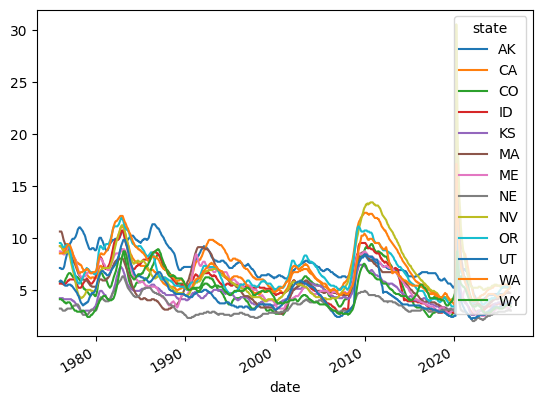

## Merge in legalization dates

Attach each state's legalization info to the panel. `cohort_year` is the recreational-vote year — states with no legalization (`ID`, `WY`, `UT`, `KS`, `NE`) get `NaN`, which is the never-treated control group.

In [6]:
panel = ur.merge(
    dates[['state', 'fips', 'recreational_vote_year']],
    on='state', how='left'
)
panel = panel.rename(columns={'recreational_vote_year': 'cohort_year'})
panel['is_treated'] = panel['cohort_year'].notna()

print(f"Treated states: {sorted(panel.loc[panel['is_treated'], 'state'].unique())}")
print(f"Control states: {sorted(panel.loc[~panel['is_treated'], 'state'].unique())}")
panel.head()

Treated states: ['AK', 'CA', 'CO', 'MA', 'ME', 'NV', 'OR', 'WA']
Control states: ['ID', 'KS', 'NE', 'UT', 'WY']


,state,date,ur,fips,cohort_year,is_treated
0,AK,1976-01-01,7.1,2,2014.0,True
1,AK,1976-02-01,7.1,2,2014.0,True
2,AK,1976-03-01,7.0,2,2014.0,True
3,AK,1976-04-01,7.0,2,2014.0,True
4,AK,1976-05-01,7.0,2,2014.0,True


In [7]:
panel = panel[panel['date'].dt.year.between(2005, 2023)]

<Axes: xlabel='date'>

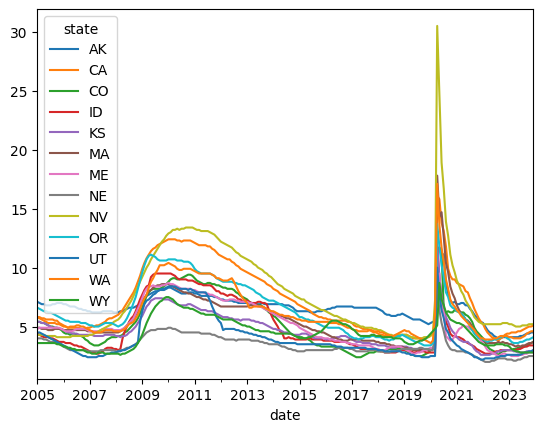

In [8]:
panel.pivot_table(index='date', columns='state', values='ur', aggfunc='max').plot()

## Check the panel is balanced

Every state should have the same number of monthly observations in the trimmed window.

In [9]:
counts = panel.groupby('state')['date'].count()
print(counts)
print('balanced:', (counts == counts.iloc[0]).all())

state
AK    228
CA    228
CO    228
ID    228
KS    228
MA    228
ME    228
NE    228
NV    228
OR    228
UT    228
WA    228
WY    228
Name: date, dtype: int64
balanced: True


## Pre-trend check

Compare treated vs. control states in years before the earliest cohort (2012) legalized. Parallel trends is about the post-period counterfactual and can't be directly tested, but if the pre-period gap is already drifting, that's a warning sign for the DiD design.

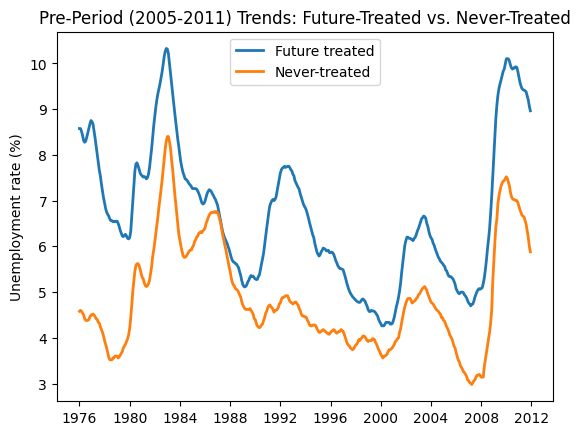

In [40]:
pre = panel[panel['date'].dt.year < 2012]
pre_avg = pre.groupby(['date', 'is_treated'])['ur'].mean().reset_index()
pre_avg['group'] = pre_avg['is_treated'].map({True: 'Future treated', False: 'Never-treated'})

fig, ax = plt.subplots()
for group, sub in pre_avg.groupby('group'):
    ax.plot(sub['date'], sub['ur'], label=group, linewidth=2)
ax.set_title('Pre-Period (2005-2011) Trends: Future-Treated vs. Never-Treated')
ax.set_ylabel('Unemployment rate (%)')
ax.legend()
plt.show()

In [41]:
pre_yearly = pre.groupby([pre['date'].dt.year, 'is_treated'])['ur'].mean().unstack()
pre_yearly.columns = ['control', 'treated']
pre_yearly['gap'] = pre_yearly['treated'] - pre_yearly['control']
pre_yearly

,control,treated,gap
date,,,
1976,4.476667,8.487500,4.010833
1977,4.336667,7.927083,3.590417
1978,3.643333,6.648958,3.005625
1979,3.761667,6.302083,2.540417
1980,5.196667,7.282292,2.085625
1981,5.360000,7.787500,2.427500
1982,7.175000,9.635417,2.460417
1983,7.491667,9.260417,1.768750
1984,5.880000,7.538542,1.658542


## Pre-trend check with state fixed effects

The raw-levels gap above is misleading partly because treated states just run higher on average — that's a level difference, not a trend difference, and state fixed effects absorb it entirely. Two ways to look at trend divergence once levels are removed:

1. Demean each state's series by its own pre-period mean and re-plot treated vs. control.
2. Regress `ur` on state fixed effects, a linear year trend, and `year:is_treated` — the interaction coefficient is the differential slope for treated states, conditional on state FE.

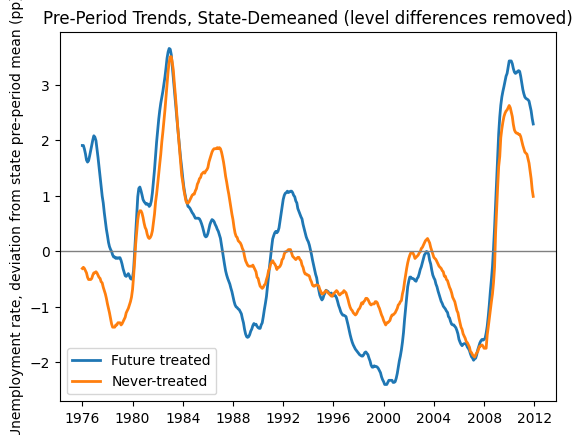

In [42]:
pre_fe = pre.copy()
pre_fe['ur_demeaned'] = pre_fe.groupby('state')['ur'].transform(lambda x: x - x.mean())

demean_avg = pre_fe.groupby(['date', 'is_treated'])['ur_demeaned'].mean().reset_index()
demean_avg['group'] = demean_avg['is_treated'].map({True: 'Future treated', False: 'Never-treated'})

fig, ax = plt.subplots()
for group, sub in demean_avg.groupby('group'):
    ax.plot(sub['date'], sub['ur_demeaned'], label=group, linewidth=2)
ax.axhline(0, color='gray', linewidth=1)
ax.set_title('Pre-Period Trends, State-Demeaned (level differences removed)')
ax.set_ylabel('Unemployment rate, deviation from state pre-period mean (pp)')
ax.legend()
plt.show()

In [43]:
pre_reg = pre.copy()
pre_reg['year'] = pre_reg['date'].dt.year

model_pretrend = smf.ols('ur ~ C(state) + year + year:is_treated', data=pre_reg).fit(
    cov_type='cluster', cov_kwds={'groups': pre_reg['state']}
)

term = 'year:is_treated[T.True]'
coef = model_pretrend.params[term]
se   = model_pretrend.bse[term]
p    = model_pretrend.pvalues[term]
ci   = model_pretrend.conf_int().loc[term]
print(f"Differential pre-trend (treated vs. control), state FE: {coef:.3f} pp/year")
print(f"  se={se:.3f}  p={p:.3f}  95% CI [{ci[0]:.3f}, {ci[1]:.3f}]")
print(f"  (only {pre_reg['state'].nunique()} state clusters -- this test is underpowered)")

Differential pre-trend (treated vs. control), state FE: -0.019 pp/year
  se=0.018  p=0.276  95% CI [-0.054, 0.016]
  (only 13 state clusters -- this test is underpowered)
